# Task 2: Stock Price Prediction

## Objective
The goal of this task is to predict the next day's stock closing price using historical stock data.

## Dataset
Yahoo Finance stock data (AAPL / TSLA) using yfinance API

## Skills Covered
- Time series data handling
- Regression modeling
- Feature engineering
- Model evaluation
- Data visualization

In [1]:
!pip install yfinance

In [21]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

stock_symbol = "TSLA" # Tesla
stock_data = yf.download(stock_symbol, start="2021-01-01", end="2026-01-01")

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(stock_data.head())

/tmp/ipykernel_11799/2999236849.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_symbol, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

First 5 Rows of Dataset:
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000
2021-01-07  272.013336  272.329987  258.399994  259.209991  154496700
2021-01-08  293.339996  294.829987  279.463318  285.333344  225166500


In [22]:
# Use Open, High, Low, Volume as input features
X = stock_data[['High', 'Low','Open', 'Volume']]

# Predict next day's Close price
y = stock_data['Close'].shift(-1)

# Remove last row (contains NaN after shifting)
X = X[:-1]
y = y[:-1]

#Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Model Evaluation:
Mean Absolute Error (MAE): 10.55
Mean Squared Error (MSE): 180.44
Root Mean Squared Error (RMSE): 13.43
R² Score: 0.9629


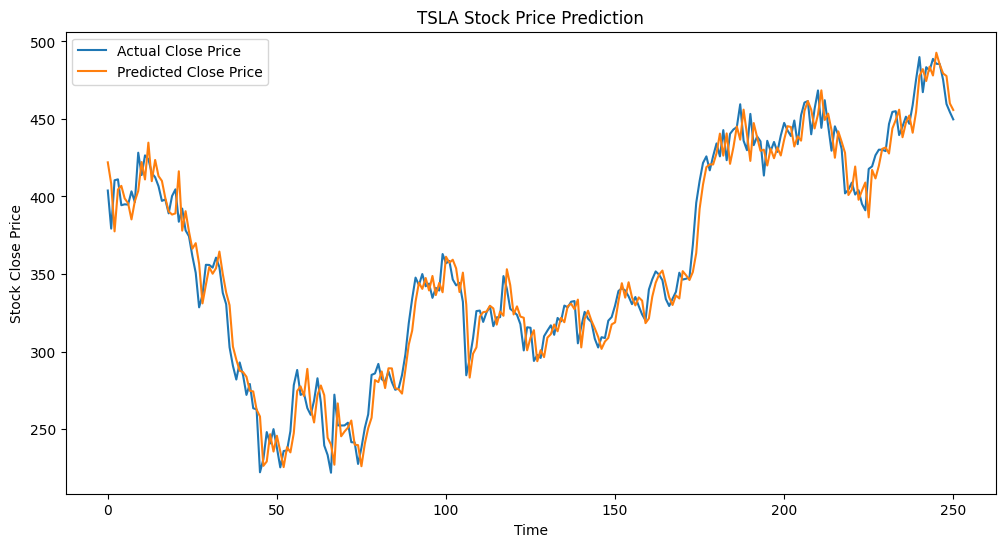

In [24]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Close Price")
plt.plot(y_pred, label="Predicted Close Price")

plt.title(f"{stock_symbol} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Close Price")
plt.legend()

plt.show()

In [25]:
latest_features = X.tail(1)
tomorrow_prediction = model.predict(latest_features)

print(f"Predicted Next Day Closing Price for Tesla ({stock_symbol}):")
print(f"${tomorrow_prediction[0][0]:.2f}")

Predicted Next Day Closing Price for Tesla (TSLA):
$455.78
